# Modelo Introducing Chronos 2

Modelado utilizando introducing-chronos-2

## Librerías

Cargamos las librerías para la experimentación

In [1]:
import json
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import mlflow
from chronos import Chronos2Pipeline

d:\Codigo\TFM_Modelado\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuraciones

Definimos las configuraciones para la experimentación

In [2]:
TRAIN_PATH = "../data/conjuntos/datos_entrenamiento.csv"
DATE_COL = "FechaMedicion"
TARGET_COL = "Potencia"
PHASE_COL = "Fase"
TEST_SIZE = 6
LISTA_MODELOS = [
    "autogluon/chronos-2-small",  # 28 M
    "amazon/chronos-2",  # 120 M
]
MODEL_ID = LISTA_MODELOS[0]
MLFLOW_URI = "http://vm-dev-docker-1.int.alephsub0.org:5000"
MLFLOW_EXPERIMENT = "TFM_Modelado_Chronos"

LISTA_FASES = [1, 2]

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

lista_regresores = ["Voltaje", "FactorPotencia", "Frecuencia"]

df = (
    pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

print(f"Datos cargados: {df.shape}")
print(f"Fases disponibles: {sorted(df[PHASE_COL].dropna().unique().tolist())}")
print(f"Tracking URI activo: {mlflow.get_tracking_uri()}")
print(f"Modelos configurados: {LISTA_MODELOS}")
print(f"Modelo activo por defecto: {MODEL_ID}")

Datos cargados: (7790, 8)
Fases disponibles: [1, 2]
Tracking URI activo: http://vm-dev-docker-1.int.alephsub0.org:5000
Modelos configurados: ['autogluon/chronos-2-small', 'amazon/chronos-2']
Modelo activo por defecto: autogluon/chronos-2-small


## Funciones auxilixares

Definimos funciones para automatizar la ejecución de los experimentos. Dado que el coste computacional es menor que ARIMA lo ejecutamos directamente en un notebok

In [7]:
def calcular_mape(y_true, y_pred, eps=1e-9):
    """
    Calcula el MAPE (Mean Absolute Percentage Error) evitando divisiones por cero.

    Args:
        y_true (array-like): Valores reales.
        y_pred (array-like): Valores predichos.
        eps (float): Offset para evitar la división por cero.
    Returns:
        float: MAPE expresado como porcentaje.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)


def calcular_metricas(test_df, pred_df, pred_col="predictions"):
    metricas = {}
    for fase in LISTA_FASES:
        gt_phase = test_df[test_df[PHASE_COL] == fase].copy()
        pred_phase = pred_df[pred_df[PHASE_COL] == fase].copy()

        if gt_phase.empty or pred_phase.empty:
            metricas[f"fase_{fase}"] = {"MAPE": np.nan, "RMSE": np.nan, "MAE": np.nan}
            continue

        joined = gt_phase[[DATE_COL, TARGET_COL]].merge(
            pred_phase[[DATE_COL, pred_col]],
            on=DATE_COL,
            how="inner",
        )

        if joined.empty:
            metricas[f"fase_{fase}"] = {"MAPE": np.nan, "RMSE": np.nan, "MAE": np.nan}
            continue

        y_true = joined[TARGET_COL].to_numpy(dtype=float)
        y_pred = joined[pred_col].to_numpy(dtype=float)

        mape = calcular_mape(y_true, y_pred)
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        metricas[f"fase_{fase}"] = {"MAPE": mape, "RMSE": rmse, "MAE": mae}

    return metricas


def graficar_resultados(test_df, pred_df, pred_col=None, low_col=None, high_col=None, show=True):
    figuras = {}

    for fase in LISTA_FASES:
        gt_phase = test_df[test_df[PHASE_COL] == fase].copy().sort_values(DATE_COL)
        pred_phase = pred_df[pred_df[PHASE_COL] == fase].copy().sort_values(DATE_COL)

        cols_pred = [DATE_COL, pred_col]
        if low_col is not None:
            cols_pred.append(low_col)
        if high_col is not None:
            cols_pred.append(high_col)

        joined = gt_phase[[DATE_COL, TARGET_COL]].merge(
            pred_phase[cols_pred],
            on=DATE_COL,
            how="inner",
        ).sort_values(DATE_COL)

        if joined.empty:
            print(f"Fase {fase}: no hay cruce de fechas entre test y predicciones.")
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(joined[DATE_COL], joined[TARGET_COL], label="Valores Reales", marker="o")
        ax.plot(joined[DATE_COL], joined[pred_col], label="Predicciones", marker="x")

        if low_col is not None and high_col is not None and low_col in joined.columns and high_col in joined.columns:
            ax.fill_between(
                joined[DATE_COL],
                joined[low_col],
                joined[high_col],
                alpha=0.4,
                label="prediction interval",
                color="orange",
            )

        ax.set_title(f"Forecast Introducing-Chronos-2 - Fase {fase}")
        ax.set_xlabel(DATE_COL)
        ax.set_ylabel(TARGET_COL)
        ax.grid()
        ax.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()

        figuras[fase] = fig

        if show:
            plt.show()
        else:
            plt.close(fig)

    return figuras


def registrar_run_mlflow(
    model_id,
    train_df,
    test_df,
    pred_df,
    metricas,
    figuras,
    pred_col="predictions",
    low_col=None,
    high_col=None,
    run_prefix="chronos2",
    device_name="unknown",
):
    run_name = f"{run_prefix}_{model_id.split('/')[-1]}"
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_family", "chronos2")
        mlflow.set_tag("model_id", model_id)
        mlflow.set_tag("framework", "Chronos2Pipeline")

        mlflow.log_params(
            {
                "train_path": TRAIN_PATH,
                "date_col": DATE_COL,
                "target_col": TARGET_COL,
                "phase_col": PHASE_COL,
                "test_size": int(TEST_SIZE),
                "device": device_name,
                "prediction_col": pred_col,
                "lower_quantile_col": low_col if low_col is not None else "none",
                "upper_quantile_col": high_col if high_col is not None else "none",
                "phase_count": int(len(LISTA_FASES)),
            }
        )

        for fase, m in metricas.items():
            fase_num = fase.replace("fase_", "")
            mlflow.log_metric(f"mape_fase_{fase_num}", float(m["MAPE"]))
            mlflow.log_metric(f"rmse_fase_{fase_num}", float(m["RMSE"]))
            mlflow.log_metric(f"mae_fase_{fase_num}", float(m["MAE"]))

        with tempfile.TemporaryDirectory() as tmp_dir:
            tmp_path = Path(tmp_dir)

            train_path = tmp_path / "dataset_train.csv"
            test_path = tmp_path / "dataset_test.csv"
            pred_path = tmp_path / "dataset_predicciones.csv"

            train_df.to_csv(train_path, index=False)
            test_df.to_csv(test_path, index=False)
            pred_df.to_csv(pred_path, index=False)
            mlflow.log_artifacts(tmp_dir, artifact_path="datasets")

        with tempfile.TemporaryDirectory() as tmp_dir:
            tmp_path = Path(tmp_dir)
            metrics_path = tmp_path / "metricas.json"
            metrics_path.write_text(json.dumps(metricas, indent=2), encoding="utf-8")
            mlflow.log_artifact(str(metrics_path), artifact_path="metrics")

        with tempfile.TemporaryDirectory() as tmp_dir:
            tmp_path = Path(tmp_dir)
            for fase, fig in figuras.items():
                fig_path = tmp_path / f"forecast_fase_{fase}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            mlflow.log_artifacts(tmp_dir, artifact_path="plots")

    for fig in figuras.values():
        plt.close(fig)

## Ajuste de los datos

In [4]:
df_modelo = df.copy()

df_modelo = (
    df_modelo[[DATE_COL, TARGET_COL, PHASE_COL] + lista_regresores]
    .dropna()
    .sort_values([PHASE_COL, DATE_COL])
    .reset_index(drop=True)
)

test_df = (
    df_modelo.groupby(PHASE_COL, group_keys=False)
    .tail(TEST_SIZE)
    .copy()
)
train_df = df_modelo.drop(index=test_df.index).copy()

# Future dataframe para Chronos (sin la columna objetivo)
future_df = test_df.drop(columns=[TARGET_COL]).copy()



## Ajuste del modelo

Parametría inicial

In [5]:
# Definimos el dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"

pred_col = "predictions"
low_col = "0.1"
high_col = "0.9"

Evaluando modelo: autogluon/chronos-2-small
Columnas de predicción:


,Fase,FechaMedicion,target_name,predictions,0.1,0.5,0.9
0,1,2026-03-14 13:20:00,Potencia,475.310699,356.778534,475.310699,622.383606
1,1,2026-03-14 13:30:00,Potencia,400.125977,293.587250,400.125977,537.980774
2,1,2026-03-14 13:40:00,Potencia,420.894379,307.836548,420.894379,567.662231
3,1,2026-03-14 13:50:00,Potencia,747.402649,584.677002,747.402649,947.911072
4,1,2026-03-14 14:00:00,Potencia,331.867554,253.575012,331.867554,460.412598
5,1,2026-03-14 14:10:00,Potencia,266.358551,207.060165,266.358551,340.478271
6,2,2026-03-14 13:20:00,Potencia,17.921326,10.896515,17.921326,22.748077
7,2,2026-03-14 13:30:00,Potencia,18.112427,10.995941,18.112427,24.655380
8,2,2026-03-14 13:40:00,Potencia,18.823532,12.180344,18.823532,25.464142
9,2,2026-03-14 13:50:00,Potencia,18.128784,11.427597,18.128784,24.799683


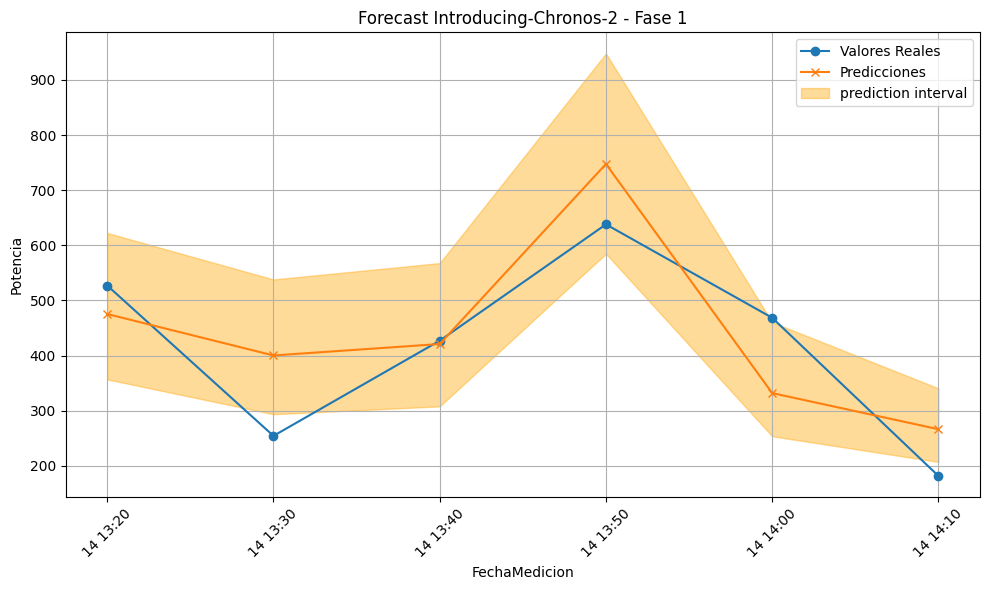

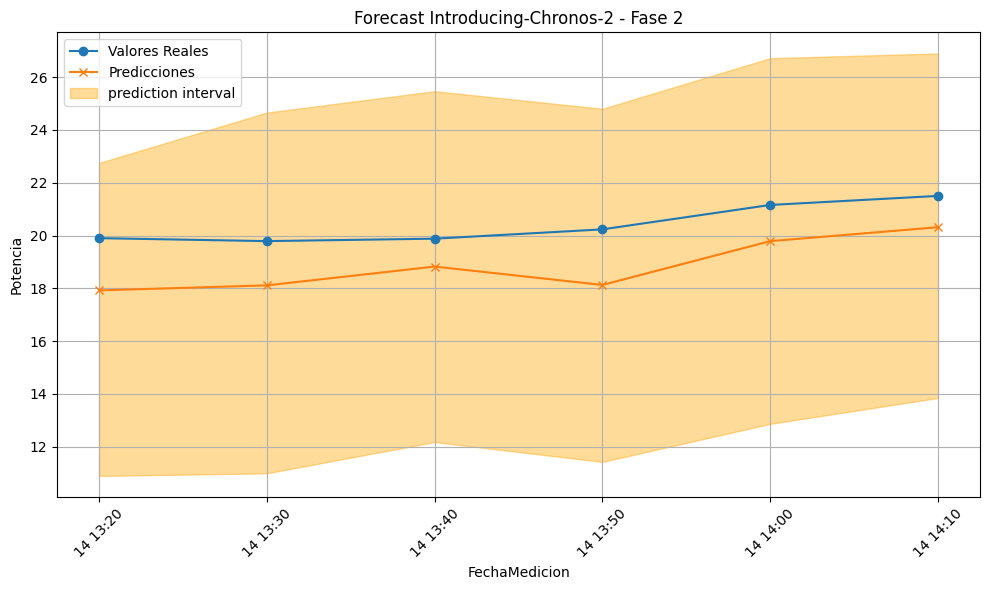

🏃 View run chronos2_chronos-2-small at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/6/runs/da01dbd644d4493cad1c54d22f214081
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/6
Métricas por fase:


,MAPE,RMSE,MAE
fase_1,26.927450,101.493570,89.060757
fase_2,7.686184,1.609882,1.561843


Evaluando modelo: amazon/chronos-2
Columnas de predicción:


,Fase,FechaMedicion,target_name,predictions,0.1,0.5,0.9
0,1,2026-03-14 13:20:00,Potencia,422.134583,323.588013,422.134583,543.673889
1,1,2026-03-14 13:30:00,Potencia,350.380371,271.426544,350.380371,452.301117
2,1,2026-03-14 13:40:00,Potencia,399.118713,306.671448,399.118713,515.216553
3,1,2026-03-14 13:50:00,Potencia,786.096924,617.100281,786.096924,992.185181
4,1,2026-03-14 14:00:00,Potencia,333.709290,258.797729,333.709290,428.163818
5,1,2026-03-14 14:10:00,Potencia,257.003754,203.530533,257.003754,322.003906
6,2,2026-03-14 13:20:00,Potencia,22.229950,17.620972,22.229950,25.459000
7,2,2026-03-14 13:30:00,Potencia,21.631180,17.622070,21.631180,25.759491
8,2,2026-03-14 13:40:00,Potencia,22.382950,17.768570,22.382950,25.859787
9,2,2026-03-14 13:50:00,Potencia,22.302551,17.674149,22.302551,26.131073


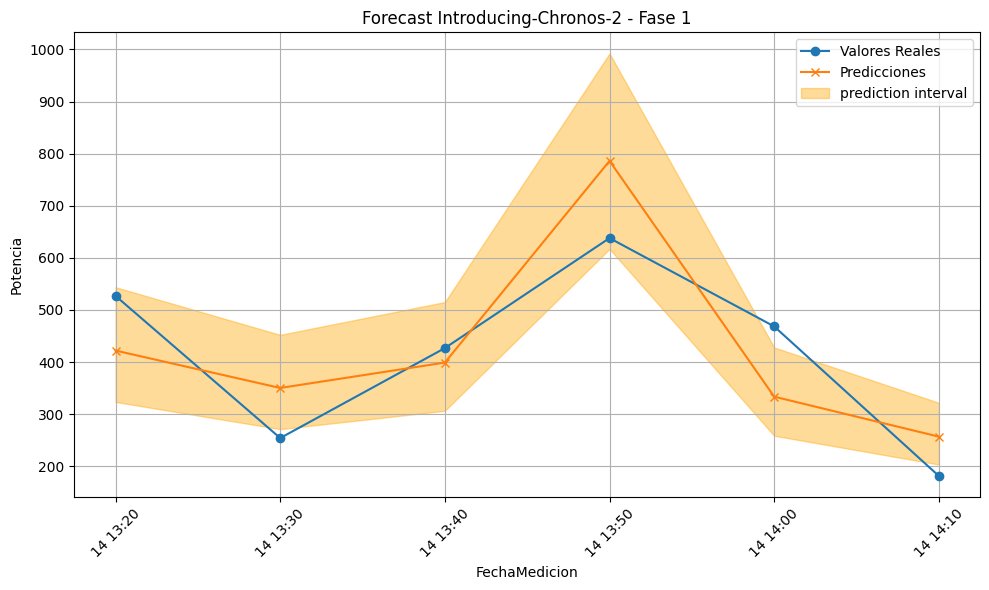

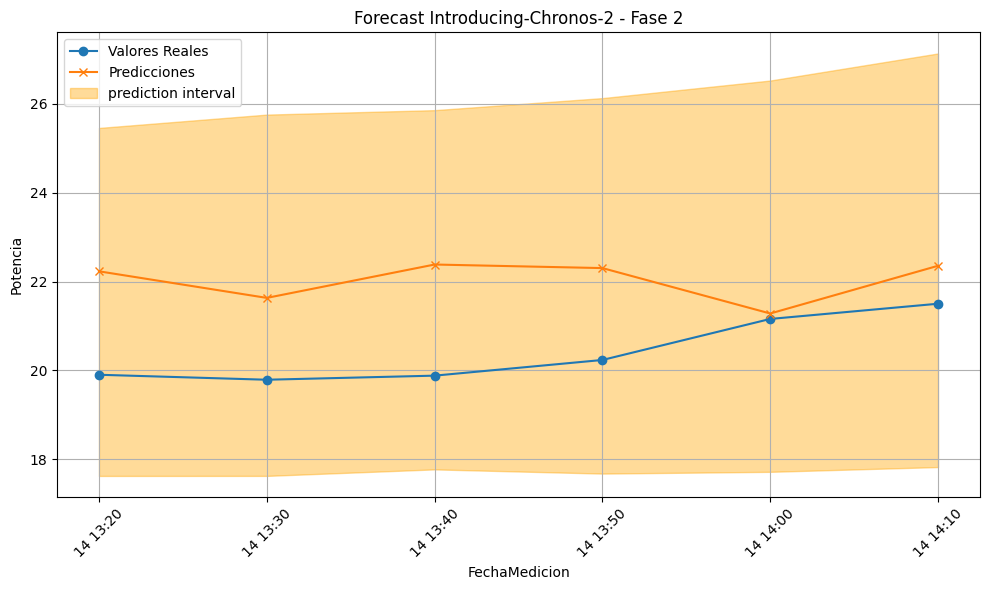

🏃 View run chronos2_chronos-2 at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/6/runs/a19095724de8424ca981b974fe0e2bee
🧪 View experiment at: http://vm-dev-docker-1.int.alephsub0.org:5000/#/experiments/6
Métricas por fase:


,MAPE,RMSE,MAE
fase_1,26.285539,105.516009,97.844744
fase_2,8.066185,1.831178,1.620505


,model_id,fase_1_mape,fase_1_rmse,fase_1_mae,fase_2_mape,fase_2_rmse,fase_2_mae
0,autogluon/chronos-2-small,26.927450,101.493570,89.060757,7.686184,1.609882,1.561843
1,amazon/chronos-2,26.285539,105.516009,97.844744,8.066185,1.831178,1.620505


In [8]:
resumen_modelos = []

for model_id in LISTA_MODELOS:
    print(f"Evaluando modelo: {model_id}")

    pipeline = Chronos2Pipeline.from_pretrained(
        model_id,
        device_map=device,
    )

    pred_df = pipeline.predict_df(
        train_df,
        future_df=future_df,
        prediction_length=TEST_SIZE,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column=PHASE_COL,
        timestamp_column=DATE_COL,
        target=TARGET_COL,
    )

    print("Columnas de predicción:")
    display(pred_df.head(12))

    figuras = graficar_resultados(
        test_df, pred_df, pred_col=pred_col, low_col=low_col, high_col=high_col, show=True
    )
    metricas = calcular_metricas(test_df, pred_df, pred_col=pred_col)

    registrar_run_mlflow(
        model_id=model_id,
        train_df=train_df,
        test_df=test_df,
        pred_df=pred_df,
        metricas=metricas,
        figuras=figuras,
        pred_col=pred_col,
        low_col=low_col,
        high_col=high_col,
        device_name=device,
    )

    print("Métricas por fase:")
    display(pd.DataFrame(metricas).T)

    resumen_modelos.append(
        {
            "model_id": model_id,
            "fase_1_mape": metricas.get("fase_1", {}).get("MAPE", np.nan),
            "fase_1_rmse": metricas.get("fase_1", {}).get("RMSE", np.nan),
            "fase_1_mae": metricas.get("fase_1", {}).get("MAE", np.nan),
            "fase_2_mape": metricas.get("fase_2", {}).get("MAPE", np.nan),
            "fase_2_rmse": metricas.get("fase_2", {}).get("RMSE", np.nan),
            "fase_2_mae": metricas.get("fase_2", {}).get("MAE", np.nan),
        }
    )

resumen_modelos_df = pd.DataFrame(resumen_modelos)
display(resumen_modelos_df)